# Level 1: Scientific Problem Framing and Python Foundation

**Course:** ICS 2207 — Scientific Computing  
**Project:** HydroSense-Kenya  
**Objective:** Translate a real irrigation problem into a computational problem using Python.

---

## 1. Problem Statement

Kenya's agricultural sector accounts for approximately 33% of the country's GDP and employs over 40% of the total population, with the majority being smallholder farmers who cultivate plots of less than two hectares. These farmers depend almost entirely on rain-fed agriculture, making them extremely vulnerable to the increasing unpredictability of rainfall patterns driven by climate change. Prolonged dry spells, erratic onset of rainy seasons, and flash floods have become more frequent across the East African region, causing significant crop losses, food insecurity, and economic hardship in rural communities.

Water scarcity is the single most critical constraint to agricultural productivity in Kenya. The country is classified as a water-scarce nation, with per-capita freshwater availability well below the global threshold of 1,000 cubic metres per year. Competing demands from urban populations, industry, and livestock further reduce the water available for crop irrigation. In this context, every litre of irrigation water must be used as efficiently as possible to sustain yields without depleting already limited water reserves.

Traditional irrigation practices in Kenya, where they exist, are overwhelmingly schedule-based. Farmers irrigate at fixed intervals regardless of actual soil moisture, recent rainfall, or crop-specific water requirements. This approach leads to two costly outcomes: over-irrigation, which wastes water and promotes waterlogging and nutrient leaching; and under-irrigation, which exposes crops to moisture stress, reduces yields, and may cause permanent crop damage during critical growth stages.

The core scientific question addressed by this project is: **Given daily weather observations and soil-sensor measurements, how can we model soil-water availability, estimate water deficit, simulate future soil-moisture trajectories under uncertain rainfall, and recommend an irrigation schedule that minimizes total water use without allowing any crop zone to fall below its minimum moisture threshold?**

HydroSense-Kenya approaches this question as a scientific computing problem. The system ingests daily weather data (rainfall, temperature, humidity, wind speed, and a solar radiation index), soil-sensor readings (moisture percentage, tank level, pump flow rate, and pump power consumption) recorded at noon across three distinct crop zones, and a parameter table that defines each zone's crop type, cultivated area, minimum acceptable moisture, target moisture, field capacity, and drainage coefficient. From these inputs, the system computes daily evapotranspiration using a simplified empirical model, updates a discrete water-balance equation to track soil-water storage over time, and identifies days on which irrigation intervention is necessary.

The project is structured around a simplified but physically meaningful water-balance model: $S_{t+1} = S_t + R_t + I_t - ET_t - D_t$, where $S_t$ is soil moisture at time $t$, $R_t$ is rainfall, $I_t$ is irrigation, $ET_t$ is evapotranspiration, and $D_t$ is drainage. Daily evapotranspiration is estimated as $ET = \max(0,\; 0.12T + 0.35W + 2.4 \cdot Solar - 0.025H)$, linking atmospheric conditions directly to crop water demand.

By framing this irrigation challenge as a computational problem, we can move beyond intuition-based farming toward data-driven, evidence-based water management. The downstream levels of this project will apply numerical methods, data analysis, simulation, Monte Carlo uncertainty modelling, and optimization to build a defensible, reproducible decision-support tool for Kenyan smallholder agriculture.

---

## 2. Load and Inspect the Datasets

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

weather = pd.read_csv('../data/raw/weather_daily.csv', na_values=['NA', ''])
soil    = pd.read_csv('../data/raw/soil_sensor_data.csv', na_values=['NA', ''])
params  = pd.read_csv('../data/raw/crop_zone_parameters.csv', na_values=['NA', ''])

weather['date'] = pd.to_datetime(weather['date'])
soil['timestamp'] = pd.to_datetime(soil['timestamp'])

print(f'weather  : {weather.shape}')
print(f'soil     : {soil.shape}')
print(f'params   : {params.shape}')

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/weather_daily.csv'

In [ ]:
weather.info()
weather.head()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            30 non-null     datetime64[us]
 1   rainfall_mm     29 non-null     float64       
 2   temperature_c   30 non-null     float64       
 3   humidity_pct    29 non-null     float64       
 4   wind_speed_mps  30 non-null     float64       
 5   solar_index     30 non-null     float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 1.5 KB


,date,rainfall_mm,temperature_c,humidity_pct,wind_speed_mps,solar_index
0,2026-03-01,3.2,23.8,69.7,2.28,0.78
1,2026-03-02,2.2,25.9,62.0,1.62,0.71
2,2026-03-03,3.0,26.8,64.4,2.11,0.75
3,2026-03-04,1.6,27.0,64.6,2.09,0.58
4,2026-03-05,23.7,26.6,61.0,1.36,0.62


In [ ]:
soil.info()
soil.head(9)

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          90 non-null     datetime64[us]
 1   zone_id            90 non-null     str           
 2   soil_moisture_pct  89 non-null     float64       
 3   tank_level_liters  90 non-null     int64         
 4   pump_flow_lpm      90 non-null     float64       
 5   pump_power_watts   90 non-null     int64         
 6   sensor_status      90 non-null     str           
dtypes: datetime64[us](1), float64(2), int64(2), str(2)
memory usage: 5.1 KB


,timestamp,zone_id,soil_moisture_pct,tank_level_liters,pump_flow_lpm,pump_power_watts,sensor_status
0,2026-03-01 12:00:00,Zone_A,33.2,4829,18.8,437,OK
1,2026-03-01 12:00:00,Zone_B,34.7,4728,22.1,461,OK
2,2026-03-01 12:00:00,Zone_C,28.2,4515,25.7,490,OK
3,2026-03-02 12:00:00,Zone_A,36.1,4757,16.6,411,OK
4,2026-03-02 12:00:00,Zone_B,32.0,4645,20.4,445,OK
5,2026-03-02 12:00:00,Zone_C,31.0,4519,24.6,492,OK
6,2026-03-03 12:00:00,Zone_A,33.7,4791,17.1,438,OK
7,2026-03-03 12:00:00,Zone_B,34.9,4603,22.1,454,OK
8,2026-03-03 12:00:00,Zone_C,28.9,4552,26.0,490,OK


In [ ]:
params

,zone_id,crop_type,area_m2,min_moisture_pct,target_moisture_pct,field_capacity_pct,drainage_coefficient
0,Zone_A,tomato,120,22,33,41,0.18
1,Zone_B,kale,90,24,35,43,0.15
2,Zone_C,maize,180,20,31,40,0.22


In [ ]:
# Missing values
print('Weather missing:', weather.isnull().sum().to_dict())
print('Soil missing:   ', soil.isnull().sum().to_dict())

Weather missing: {'date': 0, 'rainfall_mm': 1, 'temperature_c': 0, 'humidity_pct': 1, 'wind_speed_mps': 0, 'solar_index': 0}
Soil missing:    {'timestamp': 0, 'zone_id': 0, 'soil_moisture_pct': 1, 'tank_level_liters': 0, 'pump_flow_lpm': 0, 'pump_power_watts': 0, 'sensor_status': 0}


---

## 3. Data Dictionary

### weather_daily.csv

| Variable | Type | Unit | Description |
|---|---|---|---|
| `date` | datetime | YYYY-MM-DD | Calendar date of observation |
| `rainfall_mm` | float | mm | Daily cumulative rainfall. NA on Mar 8. 85.0 mm on Mar 26 (potential outlier). |
| `temperature_c` | float | °C | Mean daily air temperature. 45.8 °C on Mar 14 (extreme outlier). |
| `humidity_pct` | float | % | Mean daily relative humidity. NA on Mar 21. |
| `wind_speed_mps` | float | m/s | Mean daily wind speed. |
| `solar_index` | float | 0–1 | Dimensionless daily solar radiation index. |

### soil_sensor_data.csv

| Variable | Type | Unit | Description |
|---|---|---|---|
| `timestamp` | datetime | YYYY-MM-DD HH:MM | Noon reading time. |
| `zone_id` | string | — | Farm zone identifier (Zone_A, Zone_B, Zone_C). |
| `soil_moisture_pct` | float | % | Volumetric soil moisture. NA on Mar 6 Zone_B. 8.5% on Mar 25 Zone_B (anomaly). |
| `tank_level_liters` | int | litres | Irrigation tank water level. 9900 L on Mar 14 Zone_C (outlier). |
| `pump_flow_lpm` | float | L/min | Pump flow rate. 0.00 LPM on Mar 21 Zone_B (pump fault). |
| `pump_power_watts` | int | W | Pump electrical power draw. |
| `sensor_status` | string | — | Sensor health flag: OK or CHECK. |

### crop_zone_parameters.csv

| Variable | Type | Unit | Description |
|---|---|---|---|
| `zone_id` | string | — | Farm zone identifier. |
| `crop_type` | string | — | Crop planted (tomato, kale, maize). |
| `area_m2` | int | m² | Cultivated area of the zone. |
| `min_moisture_pct` | int | % | Minimum acceptable soil moisture before crop stress. |
| `target_moisture_pct` | int | % | Desired soil moisture for optimal growth. |
| `field_capacity_pct` | int | % | Maximum moisture before drainage begins. |
| `drainage_coefficient` | float | — | Fraction of excess moisture lost per day to drainage. |

---

## 4. Reusable Python Functions: Evapotranspiration and Water Balance

In [ ]:
def compute_evapotranspiration(temperature, wind_speed, solar_index, humidity):
    """
    Compute simplified daily evapotranspiration.
    ET = max(0, 0.12*T + 0.35*W + 2.4*Solar - 0.025*H)
    """
    et_raw = 0.12 * temperature + 0.35 * wind_speed + 2.4 * solar_index - 0.025 * humidity
    if isinstance(et_raw, (int, float)):
        return max(0.0, et_raw)
    return np.maximum(0.0, et_raw)


def compute_water_balance(S_t, rainfall, irrigation, et, drainage_coeff, field_capacity):
    """
    Compute next-day soil moisture using the discrete water-balance equation.
    S_{t+1} = S_t + R_t + I_t - ET_t - D_t
    where D_t = drainage_coeff * max(0, S_interim - field_capacity)

    Returns (S_next, D_t)
    """
    S_interim = S_t + rainfall + irrigation - et
    excess = max(0.0, S_interim - field_capacity)
    D_t = drainage_coeff * excess
    S_next = max(0.0, S_interim - D_t)
    return S_next, D_t

In [ ]:
# Quick validation with day-1 data
row = weather.iloc[0]
et_day1 = compute_evapotranspiration(
    row['temperature_c'], row['wind_speed_mps'],
    row['solar_index'], row['humidity_pct']
)
print(f'Day 1 ET = {et_day1:.4f}')

# Water balance test for Zone_A
zone_a = params[params['zone_id'] == 'Zone_A'].iloc[0]
S1, D0 = compute_water_balance(
    S_t=33.20, rainfall=3.20, irrigation=0.0, et=et_day1,
    drainage_coeff=zone_a['drainage_coefficient'],
    field_capacity=zone_a['field_capacity_pct']
)
print(f'Zone_A day 1→2: S_next={S1:.4f}%, drainage={D0:.4f}')

Day 1 ET = 3.7835
Zone_A day 1→2: S_next=32.6165%, drainage=0.0000


---

## 5. Compute ET for the Full 30-Day Period

In [ ]:
weather['ET'] = compute_evapotranspiration(
    weather['temperature_c'], weather['wind_speed_mps'],
    weather['solar_index'], weather['humidity_pct']
)

weather[['date', 'temperature_c', 'humidity_pct', 'wind_speed_mps', 'solar_index', 'ET']]

,date,temperature_c,humidity_pct,wind_speed_mps,solar_index,ET
0,2026-03-01,23.8,69.7,2.28,0.78,3.7835
1,2026-03-02,25.9,62.0,1.62,0.71,3.8290
2,2026-03-03,26.8,64.4,2.11,0.75,4.1445
3,2026-03-04,27.0,64.6,2.09,0.58,3.7485
4,2026-03-05,26.6,61.0,1.36,0.62,3.6310
5,2026-03-06,26.7,66.8,3.07,0.49,3.7845
6,2026-03-07,24.9,61.2,1.83,0.72,3.8265
7,2026-03-08,24.9,69.6,3.10,0.65,3.8930
8,2026-03-09,23.6,64.0,2.12,0.72,3.7020
9,2026-03-10,22.5,74.4,2.62,0.76,3.5810


---

## 6. Scientific Visualization: Rainfall and Soil Moisture Over Time

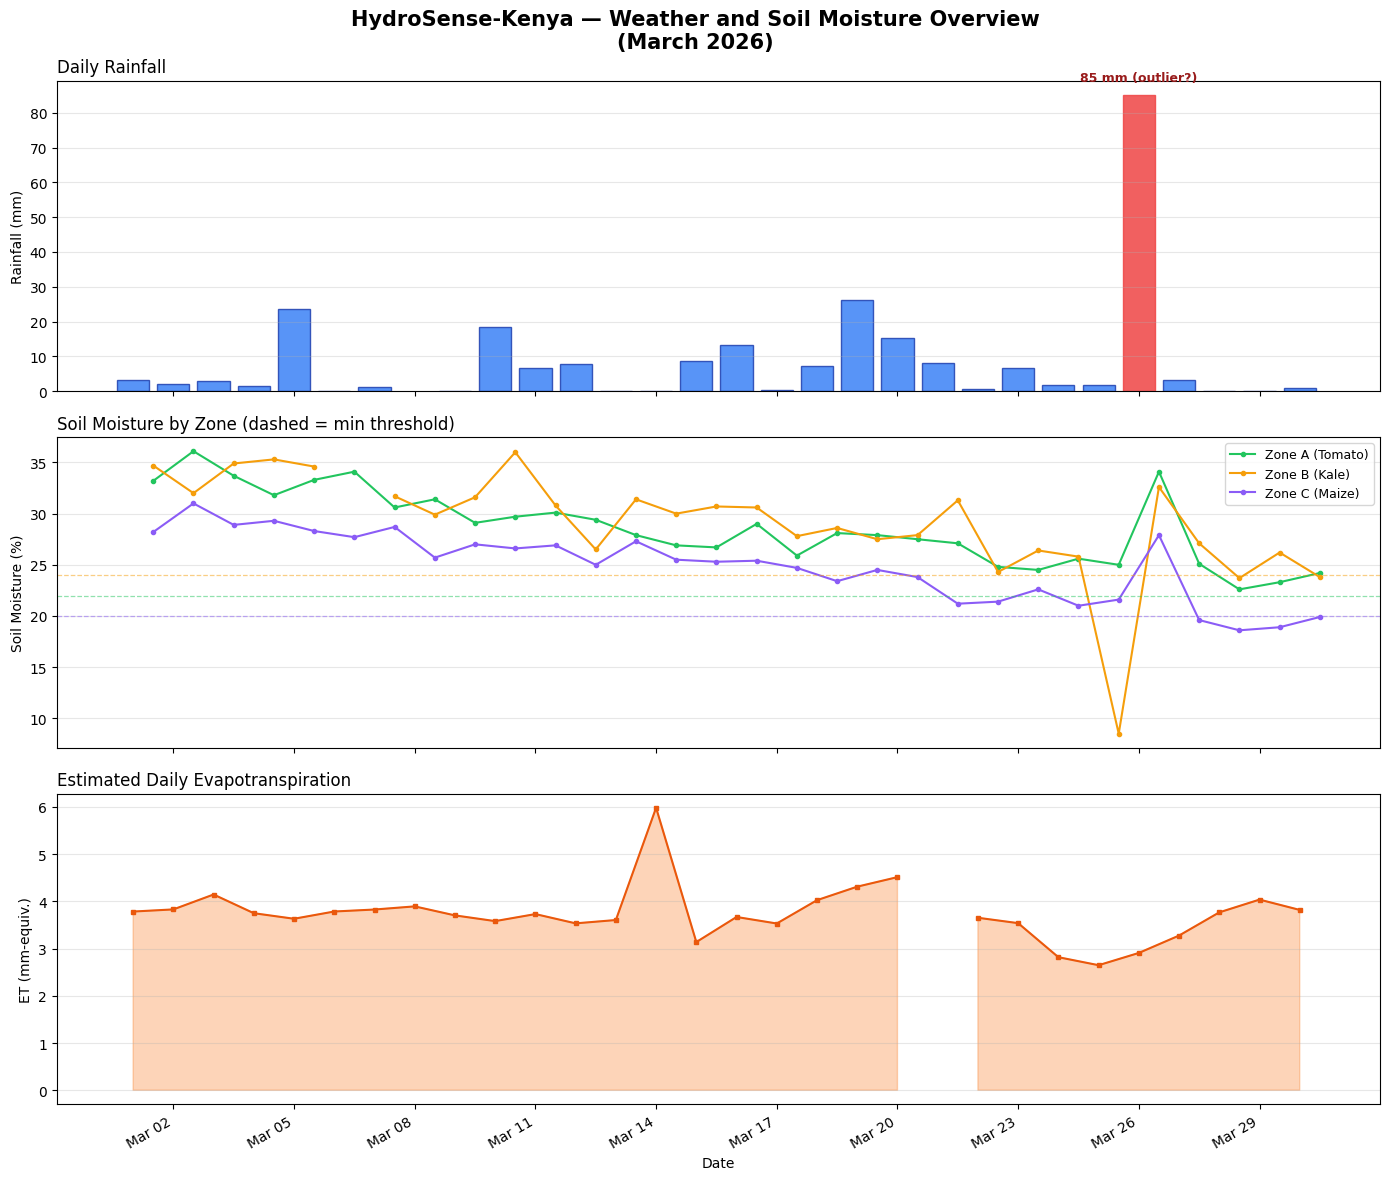

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('HydroSense-Kenya — Weather and Soil Moisture Overview\n(March 2026)',
             fontsize=15, fontweight='bold', y=0.98)

# Panel 1: Daily Rainfall
ax1 = axes[0]
bars = ax1.bar(weather['date'], weather['rainfall_mm'], color='#3b82f6',
               edgecolor='#1e40af', width=0.8, alpha=0.85)
outlier_mask = weather['rainfall_mm'] > 50
for i, is_outlier in enumerate(outlier_mask):
    if is_outlier:
        bars[i].set_color('#ef4444')
        ax1.annotate(f"{weather['rainfall_mm'].iloc[i]:.0f} mm (outlier?)",
                     xy=(weather['date'].iloc[i], weather['rainfall_mm'].iloc[i]),
                     xytext=(0, 10), textcoords='offset points',
                     ha='center', fontsize=9, color='#991b1b', fontweight='bold')
ax1.set_ylabel('Rainfall (mm)')
ax1.set_title('Daily Rainfall', loc='left')
ax1.grid(axis='y', alpha=0.3)

# Panel 2: Soil Moisture by Zone
ax2 = axes[1]
colors = {'Zone_A': '#22c55e', 'Zone_B': '#f59e0b', 'Zone_C': '#8b5cf6'}
labels = {'Zone_A': 'Zone A (Tomato)', 'Zone_B': 'Zone B (Kale)', 'Zone_C': 'Zone C (Maize)'}

for zone_id in ['Zone_A', 'Zone_B', 'Zone_C']:
    zd = soil[soil['zone_id'] == zone_id]
    ax2.plot(zd['timestamp'], zd['soil_moisture_pct'],
             marker='o', markersize=3, linewidth=1.5,
             color=colors[zone_id], label=labels[zone_id])

for _, r in params.iterrows():
    ax2.axhline(y=r['min_moisture_pct'], linestyle='--', linewidth=0.9,
                color=colors[r['zone_id']], alpha=0.5)

ax2.set_ylabel('Soil Moisture (%)')
ax2.set_title('Soil Moisture by Zone (dashed = min threshold)', loc='left')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

# Panel 3: Evapotranspiration
ax3 = axes[2]
ax3.fill_between(weather['date'], weather['ET'], alpha=0.3, color='#f97316')
ax3.plot(weather['date'], weather['ET'], color='#ea580c', linewidth=1.5,
         marker='s', markersize=3)
ax3.set_ylabel('ET (mm-equiv.)')
ax3.set_xlabel('Date')
ax3.set_title('Estimated Daily Evapotranspiration', loc='left')
ax3.grid(axis='y', alpha=0.3)

ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax3.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig('../reports/level1_overview_plot.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 7. Assumptions and Limitations

### Assumptions

1. **Simplified ET model:** The evapotranspiration formula is a linear empirical approximation. It does not account for crop growth stage, canopy cover, or soil type.

2. **Discrete daily time step:** The water-balance model updates once per day. Sub-daily dynamics are not captured.

3. **Homogeneous zones:** Each zone is treated as spatially uniform. In reality, soil properties and micro-climate vary within a zone.

4. **No runoff term:** Surface runoff is omitted. This is reasonable for flat smallholder plots under normal rainfall but under-estimates losses during extreme events.

5. **Proportional drainage:** Drainage is a fixed fraction of excess moisture above field capacity. Real drainage depends on soil hydraulic conductivity.

6. **Point sensor measurements:** Sensor readings at one depth and location are assumed representative of the entire zone.

### Limitations

1. **Short observation window (30 days):** Only March 2026 is covered — seasonal and inter-annual patterns cannot be assessed.

2. **Known data quality issues:** Missing values (rainfall Mar 8, humidity Mar 21, soil moisture Mar 6 Zone_B), outliers (temperature 45.8°C Mar 14, rainfall 85 mm Mar 26, tank 9900 L Mar 14 Zone_C), and sensor faults (pump flow 0.0 LPM Mar 21 Zone_B).

3. **No ground-truth irrigation record:** No log of actual irrigation events exists for validation.

4. **Uncalibrated ET formula:** The coefficients are not site-specific. Calibration against FAO Penman-Monteith would be needed for operational use.